# Monte Carlo Portfolio Simulation
### $250/month · 72-month horizon · Bootstrap resampling (RiskDUniform)

Two strategies:
| | SPY (S&P 500) | BIL (3-month T-Bill) |
|---|---|---|
| **Strategy 1** | 80 % | 20 % |
| **Strategy 2** | 20 % | 80 % |

Data: last 15 years of monthly total returns downloaded via **yfinance**.  
Simulation: 10 000 paths, each month's return drawn uniformly at random from
the 180 historical observations (no distributional assumption).  
Targets: **$20000** and **$25000**.


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot  as plt
import matplotlib.ticker  as mticker
import matplotlib.patches as mpatches
import yfinance as yf

from datetime import date
from dateutil.relativedelta import relativedelta

sns.set_theme(style="darkgrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False,
                     "axes.spines.right": False})
print("Libraries loaded ✓")


Libraries loaded ✓


In [2]:
# ── Download 15 years of monthly price data ───────────────────────────────────
END   = date.today().strftime("%Y-%m-%d")
START = (date.today() - relativedelta(years=15)).strftime("%Y-%m-%d")

print(f"Downloading SPY & BIL  [{START} → {END}] …")

raw = (
    yf.download(["SPY", "BIL"], start=START, end=END,
                auto_adjust=True, progress=False)
    ["Close"]                         # adjusted close
    .resample("ME")                   # month-end
    .last()                           # last trading day of month
    .dropna()
)

print(f"  → {len(raw)} monthly observations downloaded")
raw.tail(3)


  → 181 monthly observations downloaded


Ticker,BIL,SPY
Date,,
2025-12-31,91.106804,681.919983
2026-01-31,91.375999,691.969971
2026-02-28,91.599998,689.299988


In [6]:
# ── Monthly log-returns (arithmetic for portfolio math) ───────────────────────
returns = (
    raw
    .pct_change()
    .dropna()
    .rename(columns={"SPY": "spy", "BIL": "bil"})
    .assign(date=lambda df: df.index)
    .reset_index(drop=True)
)

print(f"Historical return observations: {len(returns)}")
print()
print(returns[["spy", "bil"]].describe().round(5).T.to_string())


Historical return observations: 180

        count     mean      std      min      25%      50%      75%      max
Ticker                                                                      
spy     180.0  0.01149  0.04046 -0.12487 -0.01158  0.01649  0.03627  0.12698
bil     180.0  0.00113  0.00158 -0.00044  0.00000  0.00022  0.00188  0.00497


In [13]:
# ── Simulation parameters ────────────────────────────────────────────────────
MONTHLY_CONTRIBUTION = 250          # $ per month
N_MONTHS             = 72           # horizon
N_SIMS               = 10_000       # Monte Carlo paths
TARGETS              = [20_000, 25_000]   # $ thresholds to test
RNG                  = np.random.default_rng(seed=42)

# Historical return arrays (numpy)
spy_hist = returns["spy"].to_numpy()
bil_hist = returns["bil"].to_numpy()
N_OBS    = len(spy_hist)

print(f"Observations available for bootstrap : {N_OBS}")
print(f"Monthly contribution                 : ${MONTHLY_CONTRIBUTION:,}")
print(f"Investment horizon                   : {N_MONTHS} months")
print(f"Simulations                          : {N_SIMS:,}")
print(f"Targets                              : {TARGETS}")


Observations available for bootstrap : 180
Monthly contribution                 : $250
Investment horizon                   : 72 months
Simulations                          : 10,000
Targets                              : [20000, 25000]


In [17]:
# ── Monte Carlo simulation (vectorised) ───────────────────────────────────────
# RiskDUniform: each month draws ONE historical observation uniformly at random,
# WITH REPLACEMENT — the same historical month can be picked again in any other
# month or simulation. No distributional assumption.
#
# idx shape: (N_MONTHS, N_SIMS)
#   axis 0 → each of the 72 future months
#   axis 1 → each of the 10,000 simulation paths
#
# replace=True is the default for integers(); made explicit here for clarity.
idx = RNG.integers(0, N_OBS, size=(N_MONTHS, N_SIMS), endpoint=False)

spy_draws = spy_hist[idx]   # (72, 10000) — each element independently resampled
bil_draws = bil_hist[idx]   # (72, 10000) — same idx preserves SPY/BIL correlation

def simulate_strategy(spy_w: float, bil_w: float) -> np.ndarray:
    """
    Return final portfolio values for all simulations.
    portfolio_return_t = spy_w * r_spy_t  +  bil_w * r_bil_t
    portfolio_t = portfolio_{t-1} * (1 + portfolio_return_t) + contribution
    """
    port_returns = spy_w * spy_draws + bil_w * bil_draws   # (72, 10000)
    portfolio    = np.zeros((N_MONTHS + 1, N_SIMS))

    for t in range(N_MONTHS):
        portfolio[t + 1] = (
            portfolio[t] * (1 + port_returns[t]) + MONTHLY_CONTRIBUTION
        )

    return portfolio   # shape (73, 10000)  — row 0 = start (0), rows 1..72 = end-of-month

strat1_paths = simulate_strategy(spy_w=0.80, bil_w=0.20)   # 80/20
strat2_paths = simulate_strategy(spy_w=0.20, bil_w=0.80)   # 20/80

print("Simulation complete ✓")
print(f"  Strategy 1 (80% SPY / 20% BIL)  median final value : "
      f"${np.median(strat1_paths[-1]):>10,.0f}")
print(f"  Strategy 2 (20% SPY / 80% BIL)  median final value : "
      f"${np.median(strat2_paths[-1]):>10,.0f}")
print(f"  Total invested                                      : "
      f"${MONTHLY_CONTRIBUTION * N_MONTHS:>10,.0f}")


Simulation complete ✓
  Strategy 1 (80% SPY / 20% BIL)  median final value : $    25,277
  Strategy 2 (20% SPY / 80% BIL)  median final value : $    20,203
  Total invested                                      : $    18,000


In [18]:
# ── Build tidy DataFrames via method chaining ─────────────────────────────────
def paths_to_df(paths: np.ndarray, label: str) -> pd.DataFrame:
    """Convert (73, N_SIMS) array → long-form DataFrame for seaborn."""
    return (
        pd.DataFrame(paths, columns=range(N_SIMS))          # wide
        .assign(month=lambda df: df.index)                   # add month column
        .melt(id_vars="month",
              var_name="sim",
              value_name="portfolio_value")                  # long
        .assign(strategy=label)                              # tag strategy
    )

df_all = (
    pd.concat(
        [paths_to_df(strat1_paths, "Strategy 1\n(80% SPY / 20% BIL)"),
         paths_to_df(strat2_paths, "Strategy 2\n(20% SPY / 80% BIL)")],
        ignore_index=True
    )
    .astype({"month": "int16", "sim": "int32"})
)

# Final-month slice for the CDF plots
df_final = (
    df_all
    .query("month == @N_MONTHS")
    .copy()
    .assign(
        pct_rank=lambda df: df.groupby("strategy")["portfolio_value"]
                             .rank(pct=True)
    )
)

print(f"Long-form DataFrame shape: {df_all.shape}")
df_final.groupby("strategy")["portfolio_value"].describe().round(0)


Long-form DataFrame shape: (1460000, 4)


,count,mean,std,min,25%,50%,75%,max
strategy,,,,,,,,
Strategy 1\n(80% SPY / 20% BIL),10000.0,25625.0,4404.0,13905.0,22511.0,25277.0,28412.0,47184.0
Strategy 2\n(20% SPY / 80% BIL),10000.0,20213.0,837.0,17388.0,19637.0,20203.0,20782.0,23510.0


In [19]:
# ── Descriptive statistics + probability of hitting targets ──────────────────
total_invested = MONTHLY_CONTRIBUTION * N_MONTHS

def summary(paths, name):
    finals = paths[-1]
    row = {
        "Strategy"          : name,
        "Mean ($)"          : f"{finals.mean():>10,.0f}",
        "Median ($)"        : f"{np.median(finals):>10,.0f}",
        "P10 ($)"           : f"{np.percentile(finals, 10):>10,.0f}",
        "P90 ($)"           : f"{np.percentile(finals, 90):>10,.0f}",
        "Prob > invested"   : f"{(finals > total_invested).mean()*100:.1f}%",
    }
    for t in TARGETS:
        row[f"Prob ≥ ${t:,}"] = f"{(finals >= t).mean()*100:.1f}%"
    return row

stats = pd.DataFrame([
    summary(strat1_paths, "Strategy 1  (80/20)"),
    summary(strat2_paths, "Strategy 2  (20/80)"),
])
stats.set_index("Strategy", inplace=True)
print(f"Total invested over {N_MONTHS} months: ${total_invested:,}\n")
stats


Total invested over 72 months: $18,000



,Mean ($),Median ($),P10 ($),P90 ($),Prob > invested,"Prob ≥ $20,000","Prob ≥ $25,000"
Strategy,,,,,,,
Strategy 1 (80/20),"25,625","25,277","20,219","31,363",97.3%,91.0%,52.5%
Strategy 2 (20/80),"20,213","20,203","19,133","21,297",99.7%,59.7%,0.0%


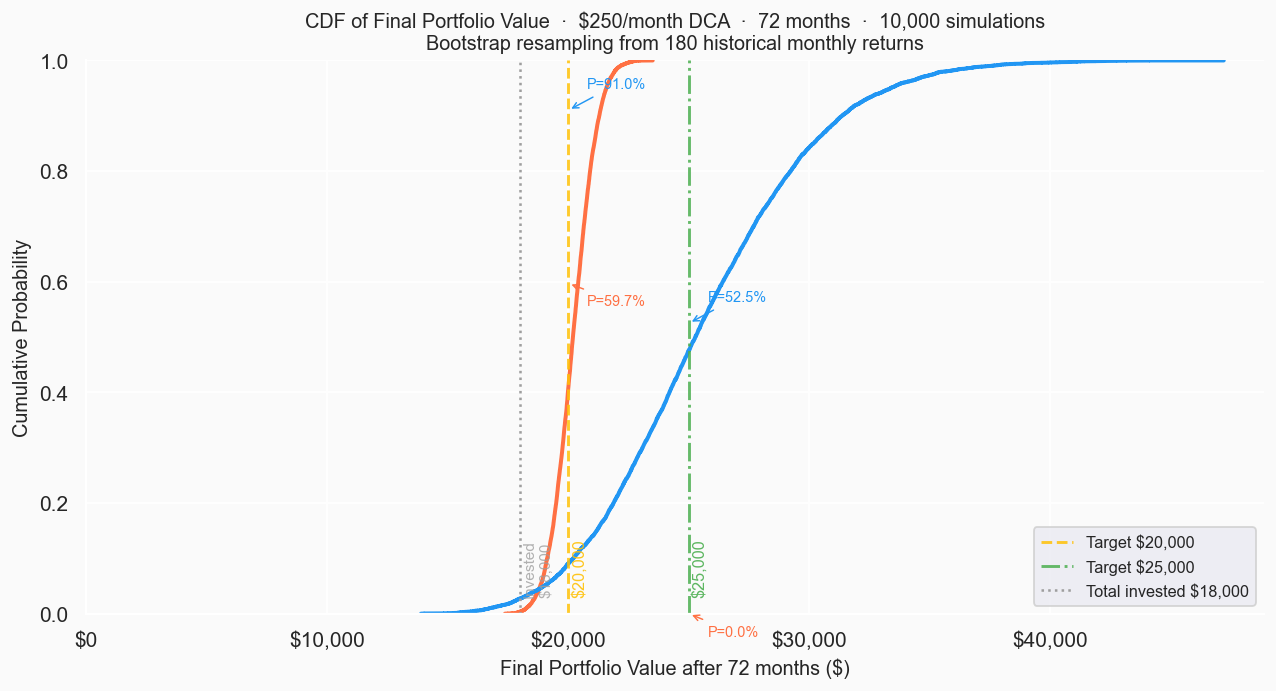

Figure saved → cdf_final_values.png


In [21]:
# ── Figure 1 · Cumulative Distribution of Final Portfolio Values ──────────────
palette = {"Strategy 1\n(80% SPY / 20% BIL)": "#2196F3",
           "Strategy 2\n(20% SPY / 80% BIL)": "#FF7043"}

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

# ECDF via seaborn – one line per strategy
(
    sns.ecdfplot(
        data=df_final,
        x="portfolio_value",
        hue="strategy",
        palette=palette,
        linewidth=2.2,
        ax=ax,
    )
)

# Target vertical lines
target_styles = {"$20,000": ("#FFC107", "--"), "$25,000": ("#4CAF50", "-.")}
for (label, val), (color, ls) in zip(
        {"$20,000": TARGETS[0], "$25,000": TARGETS[1]}.items(),
        [("#FFC107", "--"), ("#4CAF50", "-.")]
):
    ax.axvline(val, color=color, linestyle=ls, linewidth=1.6, alpha=0.85,
               label=f"Target {label}")
    ax.text(val + 120, 0.03, label, color=color, fontsize=9, va="bottom",
            rotation=90, alpha=0.9)

# Invested cost-basis line
ax.axvline(total_invested, color="#9E9E9E", linestyle=":", linewidth=1.4,
           label=f"Total invested ${total_invested:,}")
ax.text(total_invested + 120, 0.03, f"Invested\n${total_invested:,}",
        color="#9E9E9E", fontsize=8.5, va="bottom", rotation=90, alpha=0.8)

# Annotation: probability at each target per strategy
for strat_label, paths, y_pos in [
    ("Strategy 1\n(80% SPY / 20% BIL)", strat1_paths, 0.62),
    ("Strategy 2\n(20% SPY / 80% BIL)", strat2_paths, 0.38),
]:
    for t in TARGETS:
        p = (paths[-1] >= t).mean()
        ax.annotate(
            f"P={p:.1%}",
            xy=(t, p),
            xytext=(t + 800, p + 0.04 * (1 if y_pos > 0.5 else -1)),
            fontsize=8,
            color=palette[strat_label],
            arrowprops=dict(arrowstyle="->", color=palette[strat_label],
                            lw=0.8),
        )

ax.set_xlabel("Final Portfolio Value after 72 months ($)", fontsize=11)
ax.set_ylabel("Cumulative Probability", fontsize=11)
ax.set_title(
    f"CDF of Final Portfolio Value  ·  $250/month DCA  ·  72 months  ·  "
    f"{N_SIMS:,} simulations\nBootstrap resampling from {N_OBS} historical "
    f"monthly returns",
    fontsize=11,
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlim(left=0)
ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()


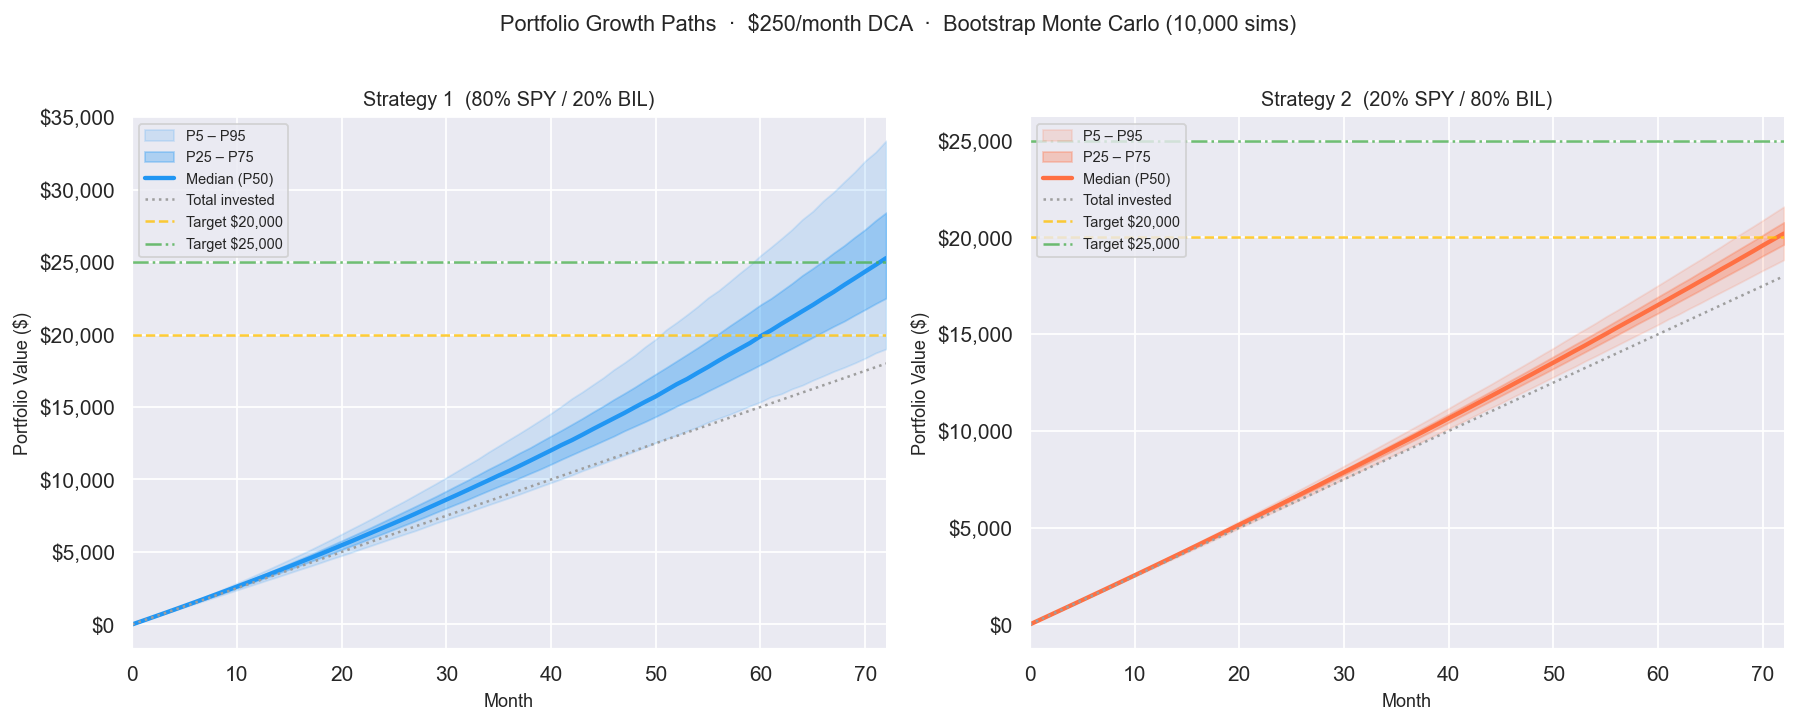

Figure saved → fan_chart_paths.png


In [23]:
# ── Figure 2 · Percentile Growth Paths (Fan Chart) ───────────────────────────
PERCS  = [5, 25, 50, 75, 95]
months = np.arange(N_MONTHS + 1)

def percentile_paths(paths):
    """Return dict {pct: array of shape (N_MONTHS+1,)} via pandas chaining."""
    return (
        pd.DataFrame(paths)                          # (73, N_SIMS)
        .apply(lambda row: pd.Series(
                   np.percentile(row, PERCS),
                   index=[f"p{p}" for p in PERCS]),
               axis=1)                               # (73, 5)
    )

pct_s1 = percentile_paths(strat1_paths)
pct_s2 = percentile_paths(strat2_paths)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)

for ax, pct_df, color_base, strat_name in [
    (axes[0], pct_s1, "#2196F3",
     "Strategy 1  (80% SPY / 20% BIL)"),
    (axes[1], pct_s2, "#FF7043",
     "Strategy 2  (20% SPY / 80% BIL)"),
]:
    # Shaded bands: P10–P90 and P25–P75
    ax.fill_between(months, pct_df["p5"], pct_df["p95"],
                    alpha=0.15, color=color_base, label="P5 – P95")
    ax.fill_between(months, pct_df["p25"], pct_df["p75"],
                    alpha=0.30, color=color_base, label="P25 – P75")

    # Median line
    ax.plot(months, pct_df["p50"], color=color_base,
            linewidth=2.4, label="Median (P50)")

    # Cost-basis line
    cost = MONTHLY_CONTRIBUTION * months
    ax.plot(months, cost, color="#9E9E9E", linestyle=":",
            linewidth=1.4, label=f"Total invested")

    # Target lines
    for t, ls, tc in zip(TARGETS, ["--", "-."], ["#FFC107", "#4CAF50"]):
        ax.axhline(t, color=tc, linestyle=ls, linewidth=1.4, alpha=0.8,
                   label=f"Target ${t:,}")

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.set_xlabel("Month", fontsize=10)
    ax.set_ylabel("Portfolio Value ($)", fontsize=10)
    ax.set_title(strat_name, fontsize=11)
    ax.legend(fontsize=8, loc="upper left")
    ax.set_xlim(0, N_MONTHS)

fig.suptitle(
    f"Portfolio Growth Paths  ·  $250/month DCA  ·  Bootstrap Monte Carlo "
    f"({N_SIMS:,} sims)",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.savefig("fan_chart_paths.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → fan_chart_paths.png")


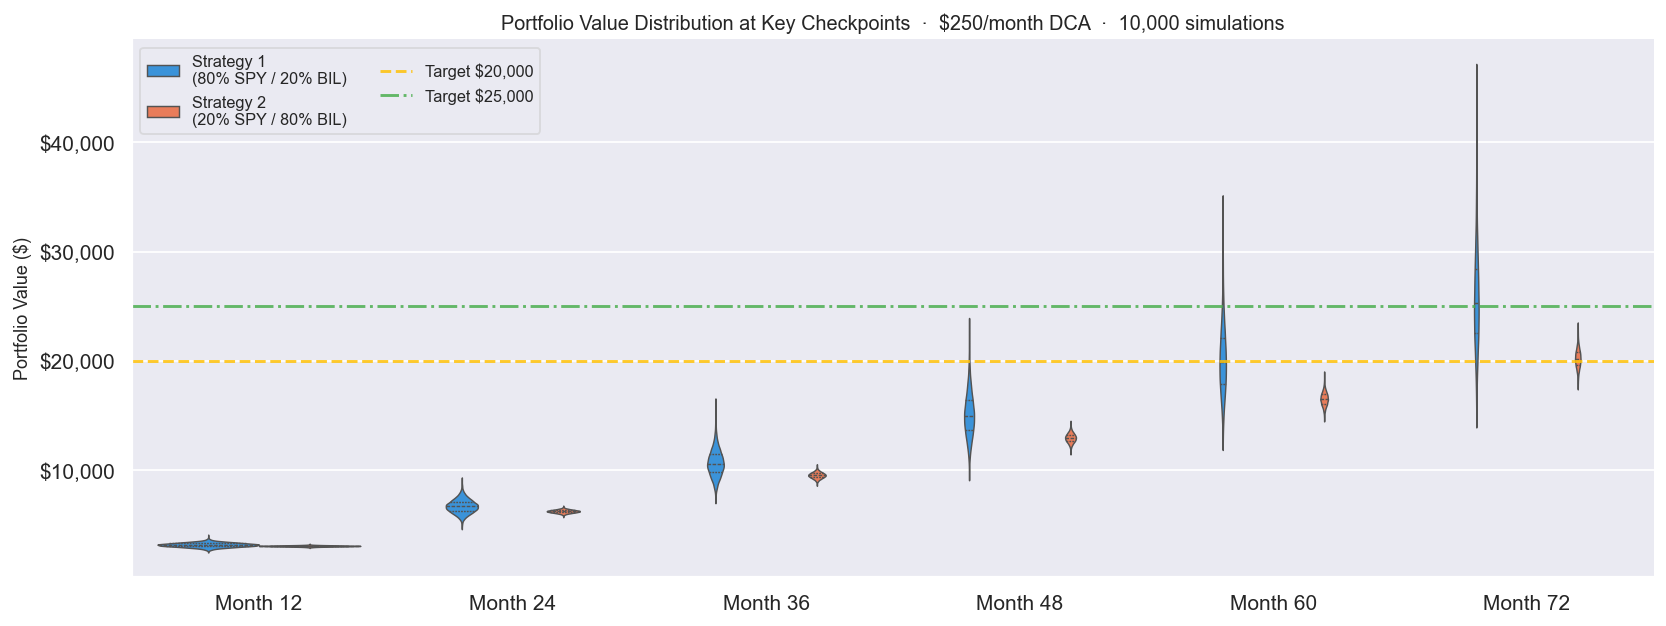

Figure saved → violin_checkpoints.png


In [24]:
# ── Figure 3 · Distribution at key checkpoints ────────────────────────────────
CHECKPOINTS = [12, 24, 36, 48, 60, 72]

df_checkpoints = (
    df_all
    .query("month in @CHECKPOINTS")
    .assign(month_label=lambda df: "Month " + df["month"].astype(str))
)

fig, ax = plt.subplots(figsize=(13, 5))

sns.violinplot(
    data=df_checkpoints,
    x="month_label",
    y="portfolio_value",
    hue="strategy",
    palette=palette,
    inner="quartile",
    linewidth=0.8,
    cut=0,
    ax=ax,
)

for t, ls, tc in zip(TARGETS, ["--", "-."], ["#FFC107", "#4CAF50"]):
    ax.axhline(t, color=tc, linestyle=ls, linewidth=1.6, alpha=0.85,
               label=f"Target ${t:,}")

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlabel("", fontsize=10)
ax.set_ylabel("Portfolio Value ($)", fontsize=10)
ax.set_title(
    "Portfolio Value Distribution at Key Checkpoints  ·  "
    f"$250/month DCA  ·  {N_SIMS:,} simulations",
    fontsize=11,
)

# Move legend outside
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="upper left", fontsize=9,
          framealpha=0.6, ncol=2)

plt.tight_layout()
plt.savefig("violin_checkpoints.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → violin_checkpoints.png")


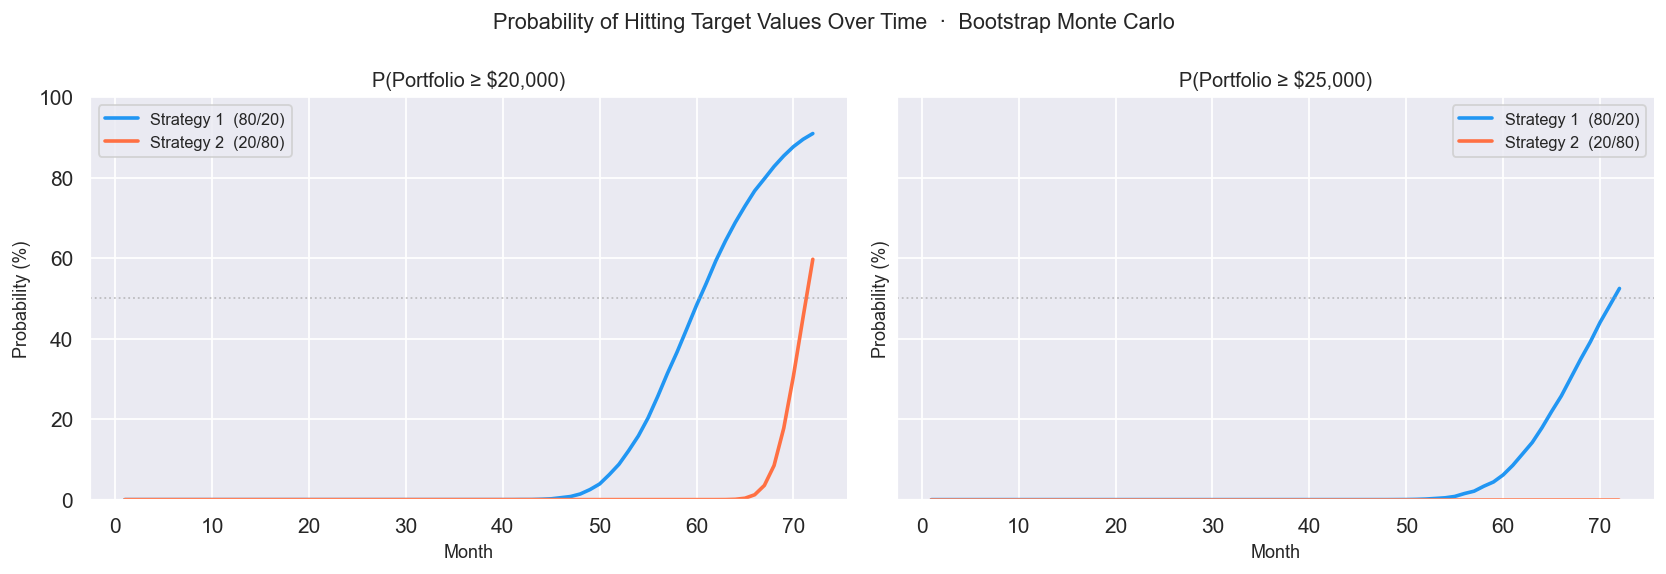


Final probabilities at month 72:
 Target Strategy 1 (80/20) Strategy 2 (20/80)
$20,000              91.0%              59.7%
$25,000              52.5%               0.0%


In [25]:
# ── Probability of hitting targets over time ─────────────────────────────────
prob_rows = []
for m in range(1, N_MONTHS + 1):
    for t in TARGETS:
        p1 = (strat1_paths[m] >= t).mean()
        p2 = (strat2_paths[m] >= t).mean()
        prob_rows.append({"Month": m, "Target": f"${t:,}",
                          "Strat1_prob": p1, "Strat2_prob": p2})

prob_df = (
    pd.DataFrame(prob_rows)
    .assign(
        diff=lambda df: df["Strat1_prob"] - df["Strat2_prob"]
    )
)

# Plot probability over time
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for ax, t_label, title in [
    (axes[0], f"${TARGETS[0]:,}", f"P(Portfolio ≥ ${TARGETS[0]:,})"),
    (axes[1], f"${TARGETS[1]:,}", f"P(Portfolio ≥ ${TARGETS[1]:,})"),
]:
    sub = prob_df.query("Target == @t_label")
    ax.plot(sub["Month"], sub["Strat1_prob"] * 100,
            color="#2196F3", linewidth=2, label="Strategy 1  (80/20)")
    ax.plot(sub["Month"], sub["Strat2_prob"] * 100,
            color="#FF7043", linewidth=2, label="Strategy 2  (20/80)")
    ax.axhline(50, color="#9E9E9E", linestyle=":", linewidth=1, alpha=0.6)
    ax.set_xlabel("Month", fontsize=10)
    ax.set_ylabel("Probability (%)", fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=9)

fig.suptitle(
    "Probability of Hitting Target Values Over Time  ·  Bootstrap Monte Carlo",
    fontsize=12,
)
plt.tight_layout()
plt.savefig("prob_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

# Final probabilities summary
print("\nFinal probabilities at month 72:")
print(
    prob_df
    .query("Month == @N_MONTHS")
    .assign(
        **{"Strategy 1 (80/20)": lambda df: (df["Strat1_prob"]*100).map("{:.1f}%".format),
           "Strategy 2 (20/80)": lambda df: (df["Strat2_prob"]*100).map("{:.1f}%".format)}
    )
    [["Target", "Strategy 1 (80/20)", "Strategy 2 (20/80)"]]
    .to_string(index=False)
)
